In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('zomato.csv', encoding='latin-1')

In [6]:
df.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [ ]:
df.shape

(9551, 21)

In [25]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Is Rated'],
      dtype='object')

In [8]:
df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [10]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

Cuisines    9
dtype: int64

In [13]:
df[df['Cuisines'].isnull()]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
84,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,34
87,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,36
94,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,...,Dollar($),No,No,No,No,1,3.9,Yellow,Good,160
297,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,...,Dollar($),No,No,No,No,3,3.9,Yellow,Good,209
328,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,...,Dollar($),No,No,No,No,3,3.8,Yellow,Good,102
346,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,11
368,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,...,Dollar($),No,No,No,No,3,4.4,Green,Very Good,1158
418,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,...,Dollar($),No,No,No,No,1,4.7,Dark Green,Excellent,707
455,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,...,Dollar($),No,No,No,No,1,3.9,Yellow,Good,309


In [18]:
df = df.dropna(subset='Cuisines')
df.shape
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['Restaurant ID'].duplicated().sum()

np.int64(0)

In [21]:
(df['Aggregate rating'] == 0).sum()

np.int64(2148)

In [23]:
df[df['Aggregate rating'] == 0]['Votes'].describe()

count    2148.000000
mean        0.870112
std         1.048600
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max         3.000000
Name: Votes, dtype: float64

In [24]:
df['Is Rated'] = df['Aggregate rating'] > 0
print(df['Is Rated'].value_counts())

Is Rated
True     7394
False    2148
Name: count, dtype: int64


In [ ]:
numeric_cols = ['Average Cost for two', 'Price range', 'Votes', 'Aggregate rating']

desc_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Std Dev': df[numeric_cols].std(),
    'Variance': df[numeric_cols].var()
})
print(desc_stats)

                             Mean  Median   Mode       Std Dev      Variance
Average Cost for two  1200.326137   400.0  500.0  16128.743876  2.601364e+08
Price range              1.804968     2.0    1.0      0.905563  8.200445e-01
Votes                  156.772060    31.0    0.0    430.203324  1.850749e+05
Aggregate rating         2.665238     3.2    0.0      1.516588  2.300038e+00


In [27]:
print(df['Currency'].value_counts())

Currency
Indian Rupees(Rs.)        8652
Dollar($)                  473
Pounds(£)                  80
Brazilian Real(R$)          60
Rand(R)                     60
Emirati Diram(AED)          60
NewZealand($)               40
Turkish Lira(TL)            34
Botswana Pula(P)            22
Indonesian Rupiah(IDR)      21
Qatari Rial(QR)             20
Sri Lankan Rupee(LKR)       20
Name: count, dtype: int64


In [31]:
city_counts = df['City'].value_counts()
top = city_counts.head(10)
top

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64

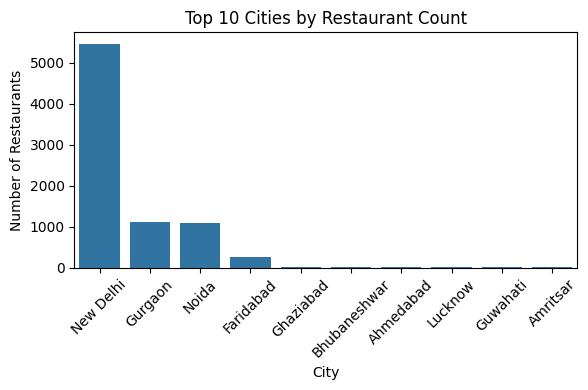

In [33]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=top.index,
    y=top.values
)

plt.title('Top 10 Cities by Restaurant Count')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
cuisine = df['Cuisines'].value_counts()
top_cuisine = cuisine.head(10)
top_cuisine

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [36]:
cuisine_rating = df[df['Aggregate rating'] > 0].groupby('Cuisines')['Aggregate rating'].mean()

print(cuisine_rating.sort_values(ascending=False).head(10))

Cuisines
European, German                   4.9
Continental, Indian                4.9
American, Coffee and Tea           4.9
American, BBQ, Sandwich            4.9
Mexican, American, Healthy Food    4.9
Italian, Deli                      4.9
American, Sandwich, Tea            4.9
Burger, Bar Food, Steak            4.9
European, Contemporary             4.9
European, Asian, Indian            4.9
Name: Aggregate rating, dtype: float64


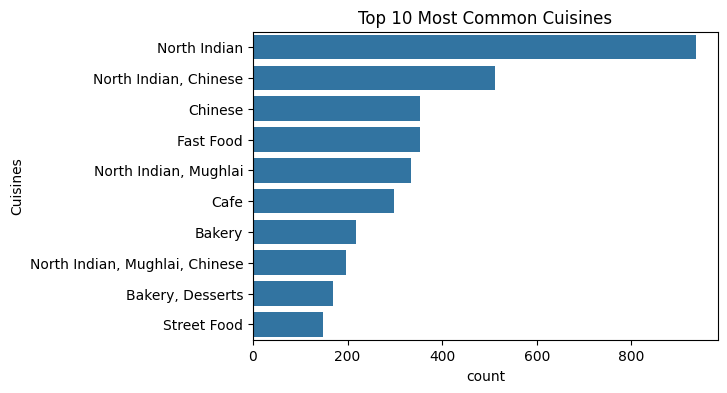

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    y='Cuisines',
    data=df,
    order=df['Cuisines'].value_counts().head(10).index
)

plt.title("Top 10 Most Common Cuisines")
plt.show()

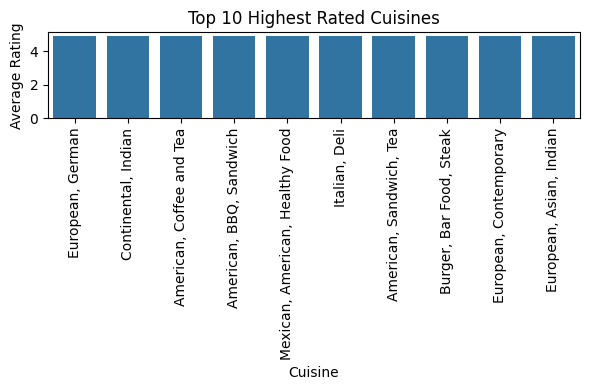

In [41]:
cuisine_rating = (
    df[df['Aggregate rating'] > 0]
    .groupby('Cuisines')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=cuisine_rating.index,
    y=cuisine_rating.values
)

plt.title('Top 10 Highest Rated Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

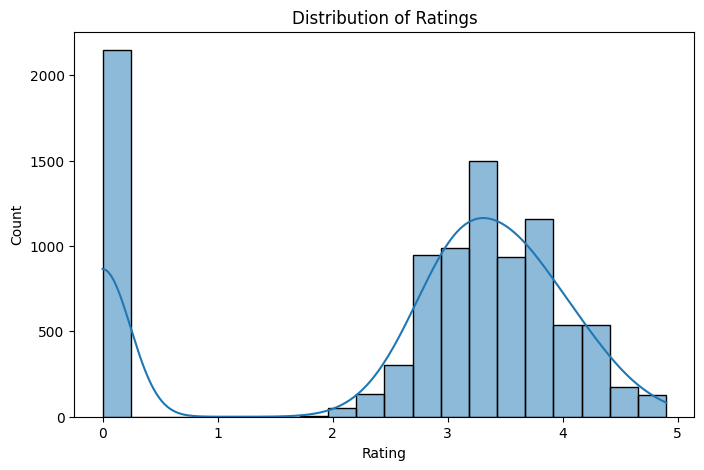

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(df['Aggregate rating'], bins=20, kde=True)

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

In [45]:
print("Skewness:", df['Aggregate rating'].skew())

Skewness: -0.953052138948468


In [46]:
Q1 = df['Aggregate rating'].quantile(0.25)
Q3 = df['Aggregate rating'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Aggregate rating'] < lower) |
    (df['Aggregate rating'] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 2148


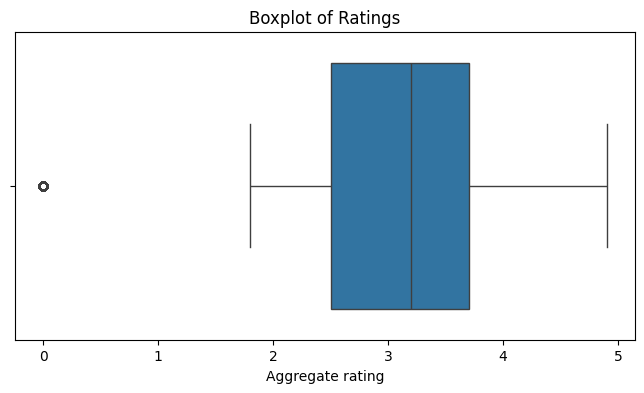

In [47]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Aggregate rating'])

plt.title('Boxplot of Ratings')

plt.show()

In [48]:
delivery_counts = df['Has Online delivery'].value_counts()

print(delivery_counts)

Has Online delivery
No     7091
Yes    2451
Name: count, dtype: int64


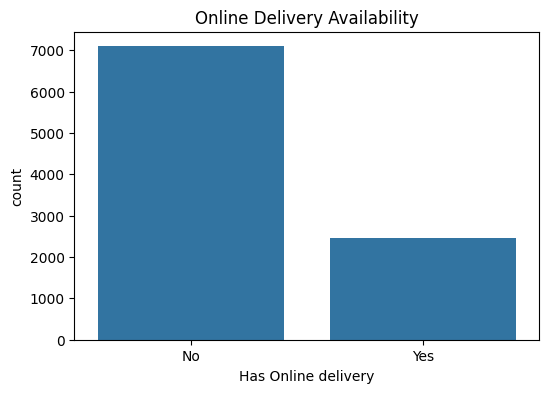

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Has Online delivery',
    data=df
)

plt.title('Online Delivery Availability')
plt.show()

In [50]:
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print(avg_rating_delivery)

Has Online delivery
No     2.463517
Yes    3.248837
Name: Aggregate rating, dtype: float64


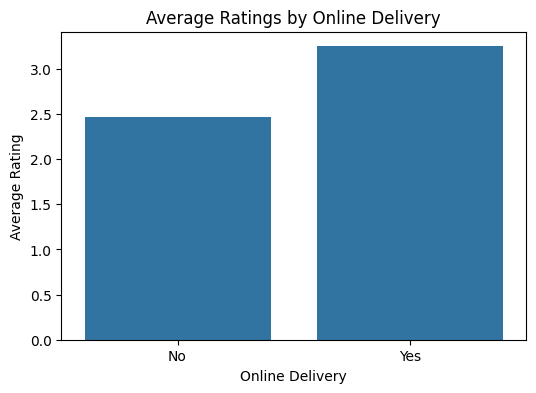

In [51]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=avg_rating_delivery.index,
    y=avg_rating_delivery.values
)

plt.title('Average Ratings by Online Delivery')
plt.xlabel('Online Delivery')
plt.ylabel('Average Rating')

plt.show()

In [55]:
print("Average Cost:", df['Average Cost for two'].mean())

Average Cost: 1200.3261370781806


In [57]:
top_expensive = df.sort_values(
    by='Average Cost for two',
    ascending=False
)

print(
    top_expensive[
        ['Restaurant Name',
         'City',
         'Average Cost for two']
    ].head(10)
)

                  Restaurant Name       City  Average Cost for two
9284     Satoo - Hotel Shangri-La    Jakarta                800000
9283                         Skye    Jakarta                800000
9287                   Sushi Masa    Jakarta                500000
9289               3 Wise Monkeys    Jakarta                450000
9294  Avec Moi Restaurant and Bar    Jakarta                350000
9295                      Onokabe  Tangerang                300000
9288   Lucky Cat Coffee & Kitchen    Jakarta                300000
9278                   Lemongrass      Bogor                250000
9285                        MONKS    Jakarta                250000
9296             Talaga Sampireun  Tangerang                200000


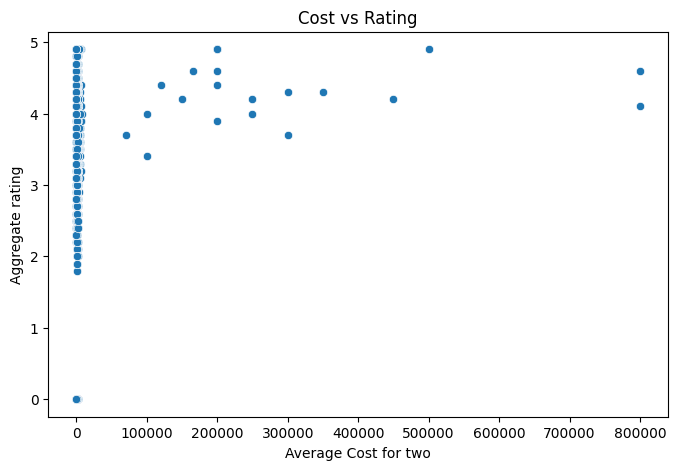

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Average Cost for two',
    y='Aggregate rating',
    data=df
)

plt.title('Cost vs Rating')
plt.show()

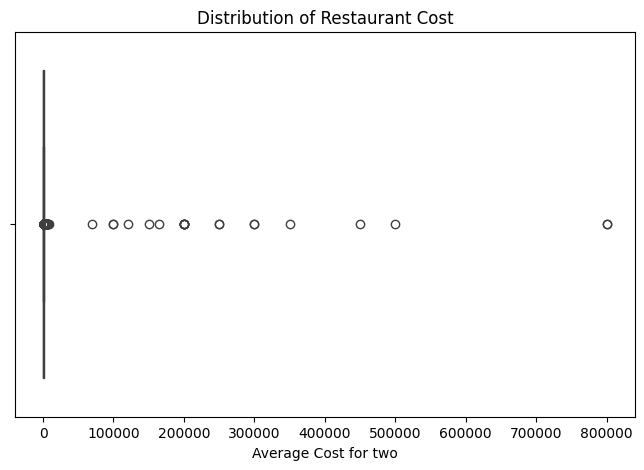

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Average Cost for two']
)

plt.title('Distribution of Restaurant Cost')
plt.show()

In [62]:
numeric_cols = df.select_dtypes(include='number')

corr_matrix = numeric_cols.corr()

print(corr_matrix)

                      Restaurant ID  Country Code  Longitude  Latitude  \
Restaurant ID              1.000000      0.146270  -0.224362 -0.052626   
Country Code               0.146270      1.000000  -0.694629  0.018049   
Longitude                 -0.224362     -0.694629   1.000000  0.045415   
Latitude                  -0.052626      0.018049   0.045415  1.000000   
Average Cost for two      -0.001629      0.043717   0.045948 -0.111080   
Price range               -0.134528      0.245363  -0.080257 -0.166735   
Aggregate rating          -0.327160      0.281295  -0.114733  0.000197   
Votes                     -0.147434      0.154361  -0.084371 -0.022914   

                      Average Cost for two  Price range  Aggregate rating  \
Restaurant ID                    -0.001629    -0.134528         -0.327160   
Country Code                      0.043717     0.245363          0.281295   
Longitude                         0.045948    -0.080257         -0.114733   
Latitude                 

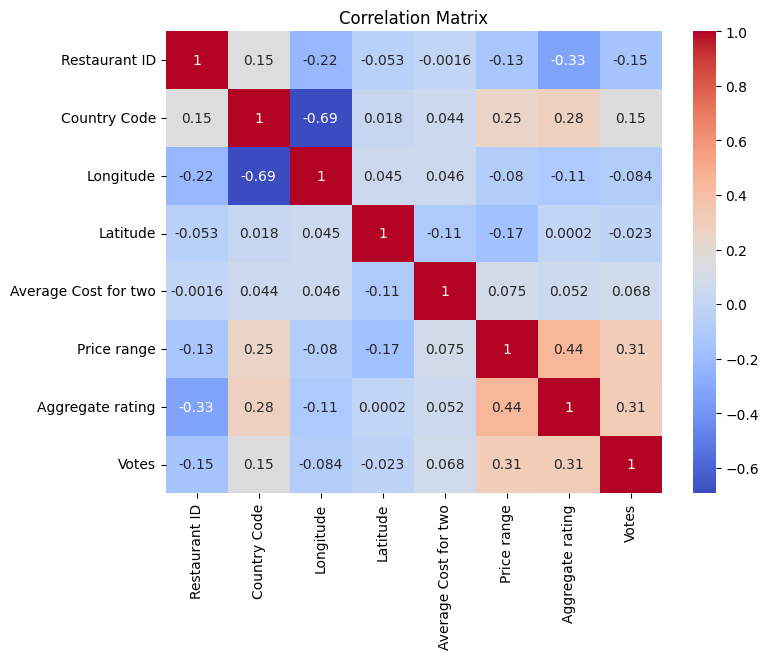

In [64]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [65]:
df['Cost Category'] = pd.cut(
    df['Average Cost for two'],
    bins=[0, 500, 1500, 5000, df['Average Cost for two'].max()],
    labels=['Budget', 'Moderate', 'Premium', 'Luxury']
)

print(df['Cost Category'].value_counts())

Cost Category
Budget      6050
Moderate    2893
Premium      552
Luxury        32
Name: count, dtype: int64


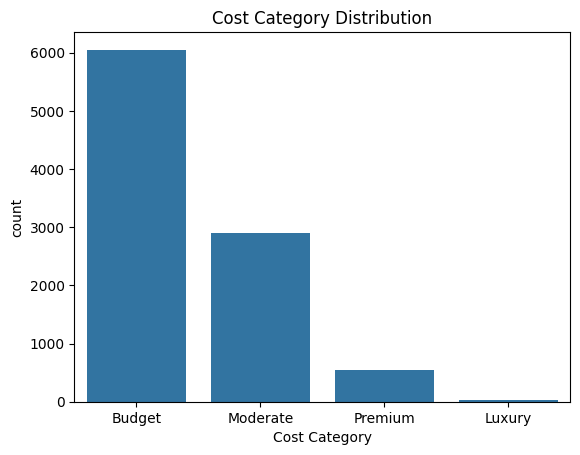

In [66]:
sns.countplot(
    x='Cost Category',
    data=df,
    order=['Budget','Moderate','Premium','Luxury']
)

plt.title('Cost Category Distribution')
plt.show()

In [67]:
df['Rating Category'] = pd.cut(
    df['Aggregate rating'],
    bins=[0, 2.5, 3.5, 4.5, 5],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

print(df['Rating Category'].value_counts())

Rating Category
Average      4104
Good         2789
Poor          296
Excellent     205
Name: count, dtype: int64


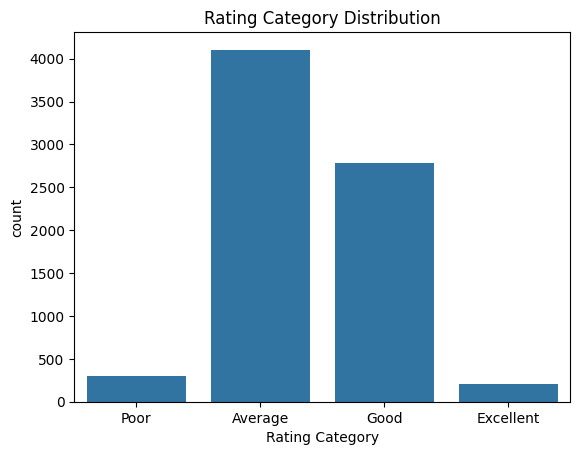

In [68]:
sns.countplot(
    x='Rating Category',
    data=df,
    order=['Poor','Average','Good','Excellent']
)

plt.title('Rating Category Distribution')
plt.show()